In [34]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [35]:
# -----------------------------
# Calibration Curve Backend
# -----------------------------

BASE = Path("data/fixed calibration data")
PLOT_DIR = Path("plots/calibration")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    "Run 1": BASE / "run 1 calibration data edit",
    "Run 2": BASE / "run 2 calibration data edit",
}

time_re = re.compile(r"^(\d+(?:\.\d+)?)ns")

def load_run(folder, drop_max_t=False):
    t_vals = []
    adc_means = []
    adc_errs = []

    for file in sorted(folder.glob("*_edit.txt")):
        m = time_re.match(file.name)
        if not m:
            continue

        t = float(m.group(1))  # ns
        data = np.loadtxt(file)

        if data.ndim == 1:
            continue

        adc = data[:, 1]
        mean = np.mean(adc)
        stderr = np.std(adc, ddof=1) / np.sqrt(len(adc))

        t_vals.append(t)
        adc_means.append(mean)
        adc_errs.append(stderr)

    t = np.array(t_vals)
    adc = np.array(adc_means)
    err = np.array(adc_errs)

    # Drop highest-t point if requested (Run 1 outlier)
    if drop_max_t and len(t) > 0:
        idx = np.argmax(t)
        t = np.delete(t, idx)
        adc = np.delete(adc, idx)
        err = np.delete(err, idx)

    return t, adc, err


def weighted_linear_fit(x, y, yerr):
    """
    Weighted least squares fit: y = m x + b
    Returns m, b, sigma_m, sigma_b
    """
    w = 1 / yerr**2
    A = np.vstack([x, np.ones_like(x)]).T

    C = np.diag(w)
    cov = np.linalg.inv(A.T @ C @ A)
    params = cov @ (A.T @ C @ y)

    m, b = params
    sigma_m = np.sqrt(cov[0, 0])
    sigma_b = np.sqrt(cov[1, 1])

    return m, b, sigma_m, sigma_b


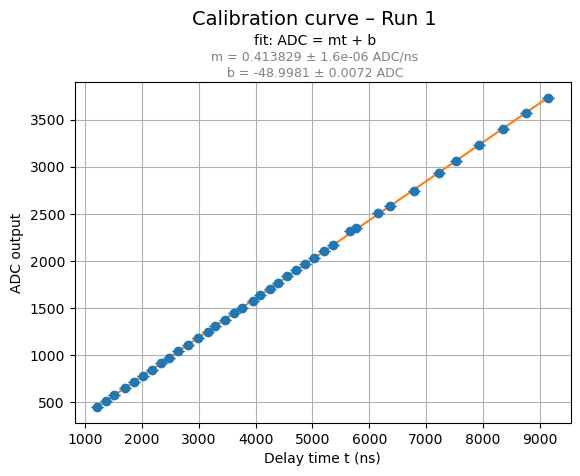

Run 1: slope m = 0.4138291660484099  (± 1.5540128162485953e-06),  intercept b = -48.99811150620917  (± 0.007224911231061503)
Saved: plots/calibration/calcurve_run1_slope=0.413829_b=-48.9981.png


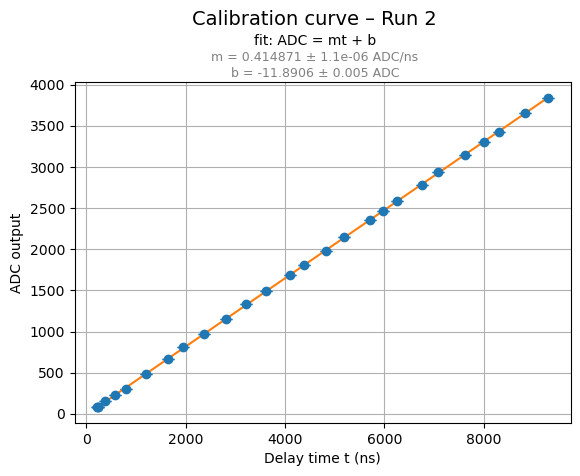

Run 2: slope m = 0.4148712263609844  (± 1.118033671834996e-06),  intercept b = -11.89057554001647  (± 0.00501864737308472)
Saved: plots/calibration/calcurve_run2_slope=0.414871_b=-11.8906.png


In [36]:
# -----------------------------
# Plot + Fit + Save
# -----------------------------
for label, folder in RUNS.items():
    # only remove outlier for run 1
    drop_outlier = (label == "Run 1")
    t, adc, err = load_run(folder, drop_max_t=drop_outlier)

    m, b, sigma_m, sigma_b = weighted_linear_fit(t, adc, err)

    t_fit = np.linspace(np.min(t), np.max(t), 300)
    adc_fit = m * t_fit + b

    # Plot
    fig, ax = plt.subplots()
    ax.errorbar(t, adc, yerr=err, fmt='o', capsize=4)
    ax.plot(t_fit, adc_fit)

    ax.set_xlabel("Delay time t (ns)")
    ax.set_ylabel("ADC output")
    ax.grid(True)

    fig.subplots_adjust(top=0.82)  # space above axes

    fig.suptitle(f"Calibration curve – {label}", fontsize=14, y=0.97)

    fig.text(0.5, 0.92, "fit: ADC = mt + b",
             ha="center", va="top", fontsize=10)

    fig.text(
        0.5, 0.885,
        f"m = {m:.6g} ± {sigma_m:.2g} ADC/ns\n"
        f"b = {b:.6g} ± {sigma_b:.2g} ADC",
        ha="center", va="top",
        fontsize=9, color="0.5", linespacing=1.3
    )

    # Save
    run_num = "1" if label == "Run 1" else "2"
    slope_str = f"{m:.6g}"
    b_str = f"{b:.6g}"
    out_name = f"calcurve_run{run_num}_slope={slope_str}_b={b_str}.png"
    out_path = PLOT_DIR / out_name

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{label}: slope m = {m}  (± {sigma_m}),  intercept b = {b}  (± {sigma_b})")
    print(f"Saved: {out_path}")
